# Phase 2: the bond book

Every auction tranche is a row; every month since 1980 is a column. The four masks from the hand-coded toy
(`main.ipynb`, Problems 1-3) are the whole engine:

    Active[i,t]      = (t >  issue[i]) & (t <= maturity[i])
    Outstanding[i,t] = (t >= issue[i]) & (t <  maturity[i])   x face
    CouponFlow[i,t]  = Active & coupon_month                  x face x coupon / 2
    Principal[i,t]   = (t == maturity[i])                      x face

computed two ways (dense masks for attribution, index-pair `bincount` for speed) that `tests/test_toy_book.py` asserts
equal. Instrument simplifications and their measured size: `docs/decisions/0004-instrument-simplifications.md`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display, Markdown
import bond_sim.notebook as nb
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 80)
plt.rcParams["figure.dpi"] = 110

# ── parameters: change and rerun ─────────────────────────────────────────────
AS_OF = pd.Timestamp("2026-09-15")     # every loader filters on this date (point-in-time contract)
K = 1000                                 # Monte Carlo paths (raise for the paper)
FORCE_REFRESH = False                  # True re-downloads every series and rebuilds cached steps
os.environ["BOND_SIM_CACHE"] = "0" if FORCE_REFRESH else "1"
import bond_sim.config as bcfg
CFG_HASH = bcfg.load().content_hash()   # every cached step is keyed by the configuration that produced it
ctx = nb.cached(f"ctx_{AS_OF.date()}_{CFG_HASH}", lambda: nb.load_context(AS_OF), refresh=FORCE_REFRESH)
print(ctx.grid, "| config hash", CFG_HASH, "| series:", ctx.w.shape[1])

MonthlyGrid(1980-01-01 .. 2056-09-01, M=921) | config hash d9222bd624fd | series: 48


11,110 tranches on MonthlyGrid(1980-01-01 .. 2056-09-01, M=921); by kind: {'bill': 8328, 'note': 1967, 'bond': 393, 'tips': 268, 'frn': 154}


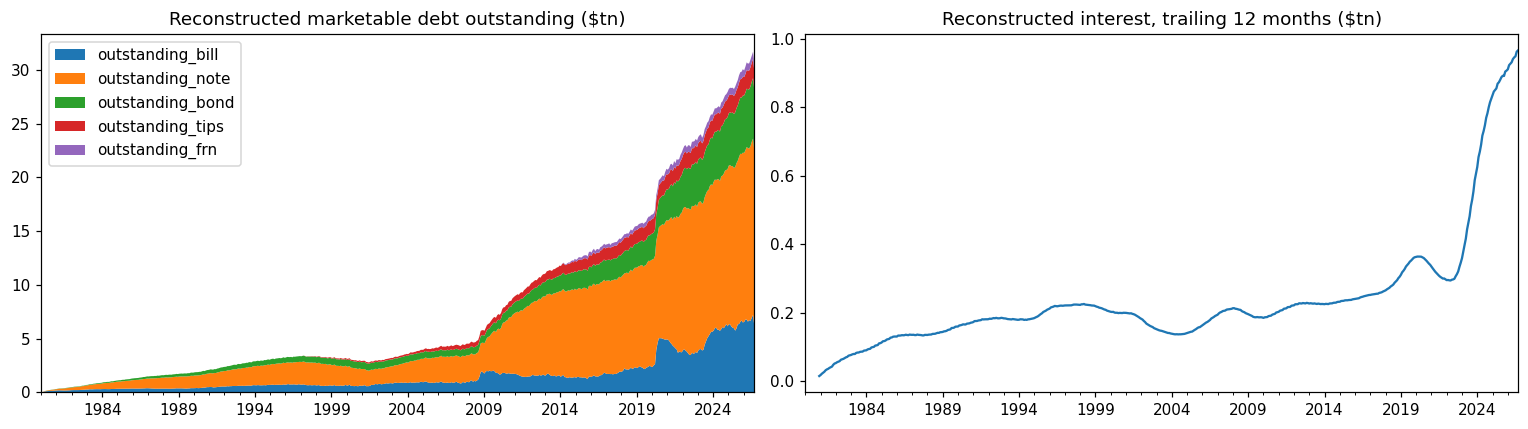

In [2]:
book, auctions, agg, short = nb.cached(f"book_{AS_OF.date()}_{CFG_HASH}", lambda: nb.build_book(ctx), refresh=FORCE_REFRESH)
print(f"{book.N:,} tranches on {ctx.grid}; by kind:", {k: int((book.kind == k).sum()) for k in ("bill", "note", "bond", "tips", "frn")})
hist = agg.loc[agg.index <= AS_OF]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
(hist[[f"outstanding_{k}" for k in ("bill", "note", "bond", "tips", "frn")]] / 1e6).plot.area(ax=ax[0], linewidth=0)
ax[0].set_title("Reconstructed marketable debt outstanding ($tn)"); ax[0].set_xlabel("")
(hist["interest"].rolling(12).sum() / 1e6).plot(ax=ax[1]); ax[1].set_title("Reconstructed interest, trailing 12 months ($tn)"); ax[1].set_xlabel("")
plt.tight_layout(); plt.show()

## 2.1 The maturity structure

How fast the stock reprices to new yields is set by its remaining maturity and its bill share. Both are read off the
book (they feed the simulator's refinancing pool, P-11), and the next five years of maturing principal is the
"maturity wall" every debt-management discussion is about.

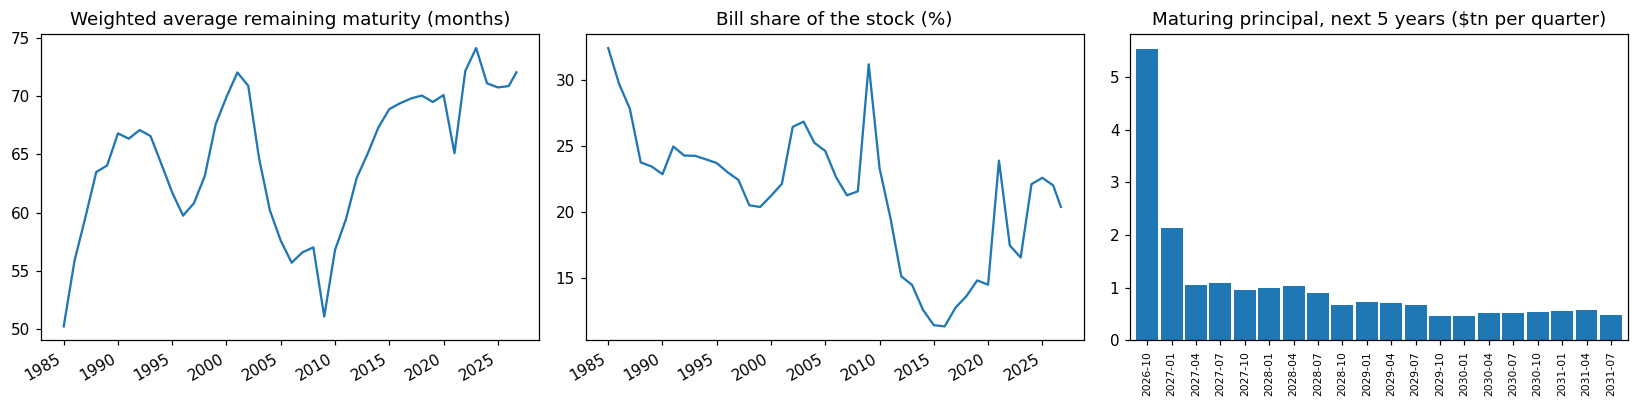

,wam_months,bill_share,outstanding_tn
date,,,
2025-01-01,70.74,0.23,28.27
2026-01-01,70.86,0.22,29.99
2026-09-15,72.04,0.20,30.62


In [3]:
prof = nb.book_profile(book, pd.date_range("1985-01-01", AS_OF, freq="YS").append(pd.DatetimeIndex([AS_OF])))
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
prof["wam_months"].plot(ax=ax[0]); ax[0].set_title("Weighted average remaining maturity (months)")
(100 * prof["bill_share"]).plot(ax=ax[1]); ax[1].set_title("Bill share of the stock (%)")
fut = agg.loc[(agg.index > AS_OF) & (agg.index <= AS_OF + pd.DateOffset(years=5)), "principal"] / 1e6
fut.resample("QS").sum().plot.bar(ax=ax[2], width=0.9); ax[2].set_title("Maturing principal, next 5 years ($tn per quarter)")
ax[2].set_xticklabels([d.strftime("%Y-%m") for d in fut.resample("QS").sum().index], rotation=90, fontsize=7)
for a in ax: a.set_xlabel("")
plt.tight_layout(); plt.show()
display(prof.tail(3).round(2))

## 2.2 Validation, not calibration

The book is compared with what the Treasury publishes and the gaps are reported, never fitted away:
* outstanding by class vs MSPD Table 1 (bills, notes, bonds, FRN within ~1.5%; TIPS at ~0.83 because the book carries
  nominal face without the inflation accrual);
* twelve-month interest vs Treasury's accrued interest expense (cash coupons vs accrual, TIPS inflation compensation);
* marketable total vs debt to the penny.

,"mean ratio book / published, last 5y"
ratio_bill,1.0080
ratio_note,1.0053
ratio_bond,1.0153
ratio_tips,0.8299
ratio_frn,0.9954
ratio_total,0.9940
ratio_interest_12m,0.8165


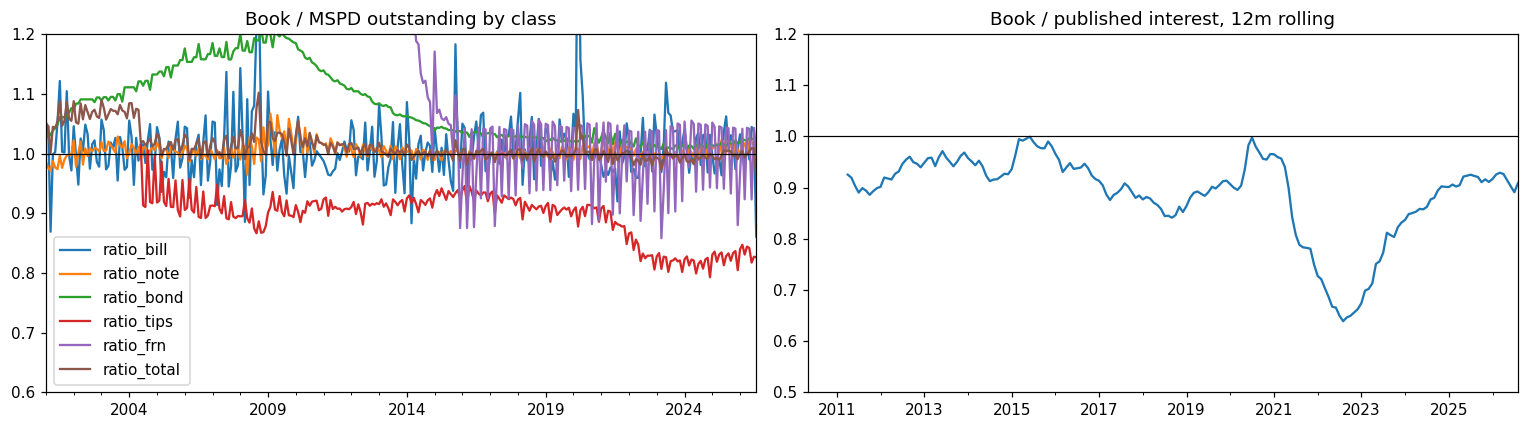

In [4]:
from bond_sim.data import load_mspd_summary, load_interest_expense, load_debt_to_penny
from bond_sim.engine.validate import BookValidator
rep = nb.cached(f"validation_{AS_OF.date()}_{CFG_HASH}", lambda: BookValidator(book).run(load_mspd_summary(as_of=AS_OF),
      load_interest_expense(as_of=AS_OF), load_debt_to_penny(as_of=AS_OF), short_rate=short), refresh=FORCE_REFRESH)
display(rep.headline().round(4).to_frame("mean ratio book / published, last 5y"))
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
rep.outstanding[[c for c in rep.outstanding.columns if c.startswith("ratio_")]].plot(ax=ax[0], ylim=(0.6, 1.2)); ax[0].axhline(1, color="k", lw=0.8)
ax[0].set_title("Book / MSPD outstanding by class"); ax[0].set_xlabel("")
rep.interest["ratio"].plot(ax=ax[1], ylim=(0.5, 1.2)); ax[1].axhline(1, color="k", lw=0.8); ax[1].set_title("Book / published interest, 12m rolling"); ax[1].set_xlabel("")
plt.tight_layout(); plt.show()

## 2.3 The bottom-up effective interest rate

The identity in Phase 4 needs `r`, the rate the stock actually pays: trailing-12-month interest divided by the stock a
year earlier. It moves as low-coupon debt rolls into new issuance, which is the interest-cost channel of the loop.
Cross-check: the Treasury's own "Average Interest Rates on U.S. Treasury Securities" (Total Marketable).

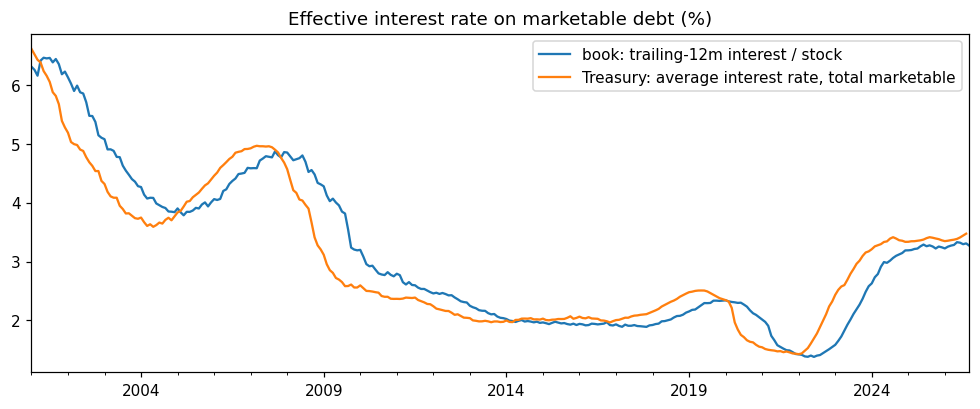

latest: book 3.27%  treasury 3.48%


In [5]:
from bond_sim.data import load_avg_interest_rates
r_eff = nb.effective_rate(agg, AS_OF)
air = load_avg_interest_rates(as_of=AS_OF)
tm = air[air.security_desc.str.contains("Total Marketable", case=False, na=False)].set_index("record_date")["avg_interest_rate_amt"]
tm.index = tm.index.to_period("M").to_timestamp()
fig, ax = plt.subplots(figsize=(11, 4))
(100 * r_eff).loc["2001":].plot(ax=ax, label="book: trailing-12m interest / stock")
tm.plot(ax=ax, label="Treasury: average interest rate, total marketable")
ax.set_title("Effective interest rate on marketable debt (%)"); ax.legend(); ax.set_xlabel(""); plt.show()
print("latest:", f"book {100*r_eff.iloc[-1]:.2f}%  treasury {tm.iloc[-1]:.2f}%")

## 2.4 Scenario discounting on the real book (Problem 5 at scale)

The present value of all future debt service under flat yield scenarios: the same `DF (K,M) @ TotalFutureCF (M,)`
collapse as the toy, now on 11,000 tranches. The simulator in Phase 5 replaces flat scenarios with simulated paths.

In [6]:
from bond_sim.engine.discount import flat_scenario_factors, present_value
cf = book.total_future_cf(ctx.t0, short_rate=short)
rates = np.array([0.02, 0.03, 0.04, 0.05, 0.06, 0.08])
pv = present_value(flat_scenario_factors(rates, book.M, periods_per_year=12), cf) / 1e6
display(pd.DataFrame({"flat yield": rates, "PV of legacy debt service ($tn)": pv.round(2)}).set_index("flat yield"))

,PV of legacy debt service ($tn)
flat yield,
0.02,12.91
0.03,7.71
0.04,4.62
0.05,2.78
0.06,1.68
0.08,0.62
